In [1]:
from pgmpy.utils import get_example_model

# Load true benchmark network
true_model = get_example_model("alarm")

# Simulate data
data = true_model.simulate(5000)

print("True edges:", len(true_model.edges()))
print("Nodes:", len(true_model.nodes()))

/Users/nunu/Documents/Masterthesis/thesisenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 276.01it/s]

True edges: 46
Nodes: 37


In [2]:
from pgmpy.estimators import GES, BIC

# Initialize GES
ges = GES(data)

# Estimate structure
learned_model = ges.estimate(scoring_method=BIC(data))

print("Learned edges:", len(learned_model.edges()))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'HRSAT': 'C', 'BP': 'C', 'PULMEMBOLUS': 'C', 'SHUNT': 'C', 'TPR': 'C', 'DISCONNECT': 'C', 'SAO2': 'C', 'VENTMACH': 'C', 'ERRCAUTER': 'C', 'HISTORY': 'C', 'PVSAT': 'C', 'INTUBATION': 'C', 'HREKG': 'C', 'INSUFFANESTH': 'C', 'MINVOLSET': 'C', 'CO': 'C', 'KINKEDTUBE': 'C', 'ARTCO2': 'C', 'HYPOVOLEMIA': 'C', 'HR': 'C', 'ERRLOWOUTPUT': 'C', 'VENTALV': 'C', 'VENTTUBE': 'C', 'VENTLUNG': 'C', 'LVFAILURE': 'C', 'CVP': 'C', 'LVEDVOLUME': 'C', 'CATECHOL': 'C', 'EXPCO2': 'C', 'STROKEVOLUME': 'C', 'HRBP': 'C', 'PCWP': 'C', 'ANAPHYLAXIS': 'C', 'PAP': 'C', 'MINVOL': 'C', 'FIO2': 'C', 'PRESS': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'HRSAT': 'C', 'BP': 'C', 'PULMEMBOLUS': 'C', 'SHUNT': 'C', 'TPR': 'C', 'DISCONNECT': 'C', 'SAO2': 'C', 'VENTMACH': 'C', 'ERRCAUTER': 'C', 'HISTORY': 'C', 'PVSAT': 'C', 'INTUBATION': 'C', 'HREKG': 'C'

Learned edges: 57


In [3]:
true_edges = set(true_model.edges())
learned_edges = set(learned_model.edges())

true_positives = len(true_edges & learned_edges)

precision = true_positives / len(learned_edges) if learned_edges else 0
recall = true_positives / len(true_edges)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

Precision: 0.333
Recall: 0.413


In [4]:
from pgmpy.utils import get_example_model
from pgmpy.estimators import GES, BIC

true_model = get_example_model("alarm")
data = true_model.simulate(5000)

ges = GES(data)
learned_model = ges.estimate(scoring_method=BIC(data))

print("True edges:", len(true_model.edges()))
print("Learned edges:", len(learned_model.edges()))

Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 297.37it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'HRSAT': 'C', 'BP': 'C', 'PULMEMBOLUS': 'C', 'SHUNT': 'C', 'TPR': 'C', 'DISCONNECT': 'C', 'SAO2': 'C', 'VENTMACH': 'C', 'ERRCAUTER': 'C', 'HISTORY': 'C', 'PVSAT': 'C', 'INTUBATION': 'C', 'HREKG': 'C', 'INSUFFANESTH': 'C', 'MINVOLSET': 'C', 'CO': 'C', 'KINKEDTUBE': 'C', 'ARTCO2': 'C', 'HYPOVOLEMIA': 'C', 'HR': 'C', 'ERRLOWOUTPUT': 'C', 'VENTALV': 'C', 'VENTTUBE': 'C', 'VENTLUNG': 'C', 'LVFAILURE': 'C', 'CVP': 'C', 'LVEDVOLUME': 'C', 'CATECHOL': 'C', 'EXPCO2': 'C', 'STROKEVOLUME': 'C', 'HRBP': 'C', 'PCWP': 'C', 'ANAPHYLAXIS': 'C', 'PAP': 'C', 'MINVOL': 'C', 'FIO2': 'C', 'PRESS': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'HRSAT': 'C', 'BP': 'C', 'PULMEMBOLUS': 'C', 'SHUNT': 'C', 'TPR': 'C', 'DISCONNECT': 'C', 'SAO2': 'C', 'VENTMACH': 'C', 'ERRC

True edges: 46
Learned edges: 55


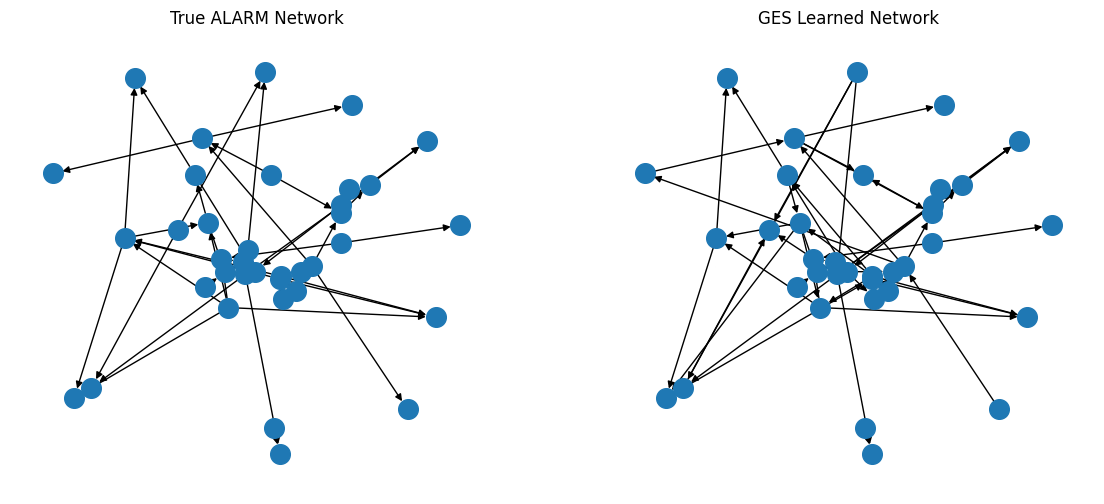

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert to networkx DiGraph
true_graph = nx.DiGraph(true_model.edges())
learned_graph = nx.DiGraph(learned_model.edges())

# Use same layout for fair comparison
pos = nx.spring_layout(true_graph, seed=42)

plt.figure(figsize=(14, 6))

# True graph
plt.subplot(1, 2, 1)
nx.draw(true_graph, pos, with_labels=False, node_size=200)
plt.title("True ALARM Network")

# Learned graph
plt.subplot(1, 2, 2)
nx.draw(learned_graph, pos, with_labels=False, node_size=200)
plt.title("GES Learned Network")

plt.show()